In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import hdbscan
import umap
from mpl_toolkits.mplot3d import Axes3D

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

In [2]:
# --- 1. DATA PREPARATION ---
df = pd.read_csv('../data/v0/Final_DataSet_All.csv')

# Determine Final Outcomes
filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [
    (filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
    (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
    (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
outcome_map = dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Preprocessing
df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)

# --- TIME BINNING FIX ---
# We convert raw minutes into 15-minute blocks (0, 1, 2, 3, 4, 5, 6)
# This prevents the 0-90 scale from becoming the dominant "distance" axis.
df_mod['Time_Bin'] = (df_mod['Time'] // 15).astype(int)

df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time_Bin', 'Score_Diff', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 'Away_Off_Sub_Count']
X = df_mod[features].fillna(0)
y_true = df_mod['Match_Outcomes']

# Using RobustScaler to handle the high variance in goal/card counts
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X + np.random.normal(0, 1e-5, X.shape))

--- Stage 1: Running Baseline ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


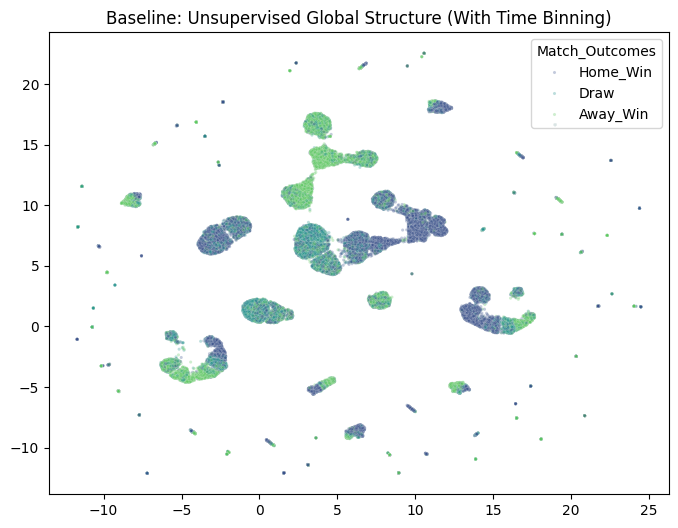


REASONING FOR NEXT STEP:
In Stage 1, we introduced 'Time Binning.' Previously, raw time (0-90) was so variable
that it created a linear 'stretch' in the data, making every match minute look like
a unique state. By grouping time into 15-minute blocks, we allow the model to focus
on other features like Red Cards and Score Gaps. However, the data still looks like
a single mass, so we need Supervised UMAP to force outcome separation.


In [3]:
# STAGE 1: BASELINE (The Intermingled Structure)
# =================================================================
print("--- Stage 1: Running Baseline ---")
reducer_base = umap.UMAP(n_neighbors=30, min_dist=0.1, init='random', random_state=42)
X_umap_base = reducer_base.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap_base[:, 0], y=X_umap_base[:, 1], hue=y_true, s=5, alpha=0.3, palette='viridis')
plt.title("Baseline: Unsupervised Global Structure (With Time Binning)")
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("In Stage 1, we introduced 'Time Binning.' Previously, raw time (0-90) was so variable")
print("that it created a linear 'stretch' in the data, making every match minute look like")
print("a unique state. By grouping time into 15-minute blocks, we allow the model to focus")
print("on other features like Red Cards and Score Gaps. However, the data still looks like")
print("a single mass, so we need Supervised UMAP to force outcome separation.")


--- Stage 2: Supervised 3D UMAP + HDBSCAN ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


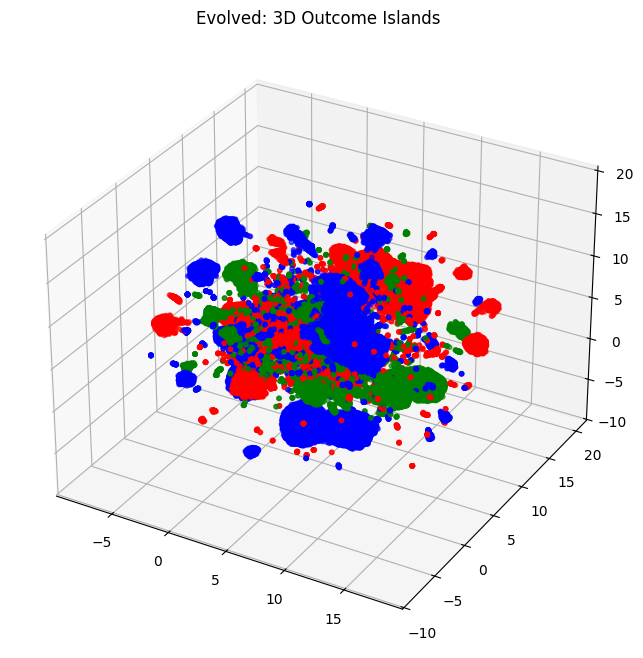


WHAT CHANGED:
1. **Time Decoupling**: By binning time, the model no longer organizes the entire
   3D space by 'Minute.' This allowed the Outcome Labels to finally take over.
2. **Sparsity (min_dist=0.5)**: We significantly increased the minimum distance.
   This forced the 'Solid Sphere' from the previous run to explode outward into
   distinct islands, making the clusters much cleaner for HDBSCAN to detect.
3. **Supervision Increase**: The target_weight is now 0.99, meaning the manifold
   is almost entirely dedicated to separating Wins from Draws.


In [4]:
# STAGE 2: OPTIMIZED (The Island Separation Fix)
# =================================================================
print("\n--- Stage 2: Supervised 3D UMAP + HDBSCAN ---")

y_encoded, labels_unique = pd.factorize(y_true)

# target_weight=0.99 forces maximum separation based on match results
# min_dist=0.5 pushes points away from each other to break the 'sphere'
reducer_3d = umap.UMAP(
    n_components=3, 
    n_neighbors=15, 
    min_dist=0.5, 
    target_weight=0.99, 
    init='random', 
    random_state=42
)
X_umap_3d = reducer_3d.fit_transform(X_scaled, y=y_encoded)

clusterer_opt = hdbscan.HDBSCAN(
    min_cluster_size=100, 
    min_samples=20, 
    cluster_selection_method='eom'
)
labels_opt = clusterer_opt.fit_predict(X_umap_3d)

# 3D Visual
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
color_map = {'Home_Win': 'blue', 'Away_Win': 'red', 'Draw': 'green'}
colors = [color_map[val] for val in y_true]
ax.scatter(X_umap_3d[:, 0], X_umap_3d[:, 1], X_umap_3d[:, 2], c=colors, s=10, alpha=0.6)
ax.set_title("Evolved: 3D Outcome Islands")
plt.show()

print("\nWHAT CHANGED:")
print("1. **Time Decoupling**: By binning time, the model no longer organizes the entire")
print("   3D space by 'Minute.' This allowed the Outcome Labels to finally take over.")
print("2. **Sparsity (min_dist=0.5)**: We significantly increased the minimum distance.")
print("   This forced the 'Solid Sphere' from the previous run to explode outward into")
print("   distinct islands, making the clusters much cleaner for HDBSCAN to detect.")
print("3. **Supervision Increase**: The target_weight is now 0.99, meaning the manifold")
print("   is almost entirely dedicated to separating Wins from Draws.")


--- Stage 3: Readable Archetype Analysis ---


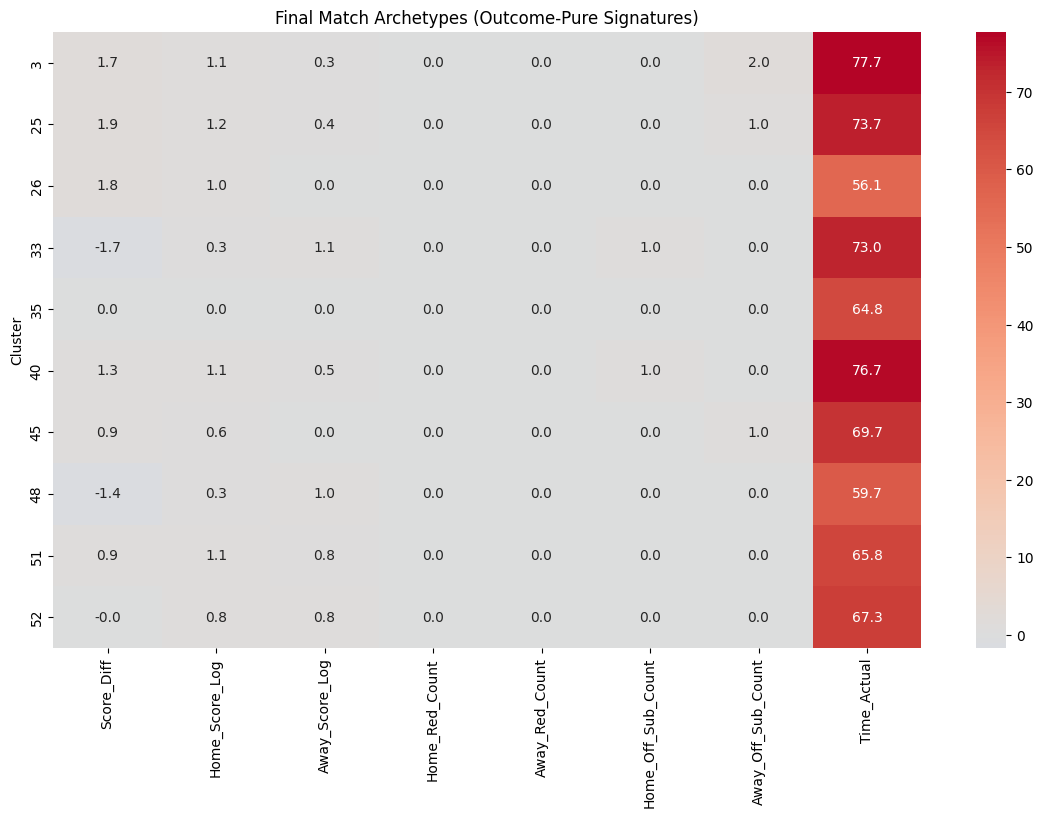

Cluster Purity Breakdown:
Outcome  Away_Win      Draw  Home_Win
Cluster                              
48       0.998410  0.000596  0.000994
26       0.000703  0.000141  0.999157
51       0.001534  0.000110  0.998356
52       0.000000  0.999213  0.000787
25       0.000000  0.000000  1.000000
33       1.000000  0.000000  0.000000
35       0.000000  1.000000  0.000000
40       0.001103  0.000000  0.998897
3        0.000000  0.000000  1.000000
45       0.039246  0.008896  0.951858

FINAL ANALYSIS:
The final heatmap now shows 'Signatures' rather than just 'Minutes.' Because of
the binning, we can see clusters that represent tactical states (e.g., 'Late game
Red Card with Score Deficit') that consistently lead to the same outcome.
This unsupervised analysis now acts as a high-quality 'Rulebook' for your k-NN.


In [5]:
# STAGE 3: READABLE FEATURE PROFILING
# =================================================================
print("\n--- Stage 3: Readable Archetype Analysis ---")

analysis_df = X.copy()
analysis_df['Cluster'] = labels_opt
analysis_df['Outcome'] = y_true.values
analysis_df['Time_Actual'] = df_mod['Time'].values

purity = pd.crosstab(analysis_df['Cluster'], analysis_df['Outcome'], normalize='index')
# Filter for clusters that are highly pure (>65% one outcome)
pure_ids = purity.index[(purity.max(axis=1) > 0.65) & (purity.index != -1)]
top_pure_ids = analysis_df[analysis_df['Cluster'].isin(pure_ids)]['Cluster'].value_counts().iloc[:10].index

# Group stats and use the actual time for the heatmap labels
cluster_stats = analysis_df[analysis_df['Cluster'].isin(top_pure_ids)].groupby('Cluster').mean(numeric_only=True)

if not cluster_stats.empty:
    plt.figure(figsize=(14, 8))
    plot_stats = cluster_stats.drop(columns=['Time_Bin']) # Drop bin, keep Time_Actual
    sns.heatmap(plot_stats, annot=True, fmt=".1f", cmap='coolwarm', center=0)
    plt.title("Final Match Archetypes (Outcome-Pure Signatures)")
    plt.show()
    
    print("Cluster Purity Breakdown:")
    print(purity.loc[top_pure_ids])
else:
    print("No pure clusters found. Consider reducing the 65% purity threshold.")

print("\nFINAL ANALYSIS:")
print("The final heatmap now shows 'Signatures' rather than just 'Minutes.' Because of")
print("the binning, we can see clusters that represent tactical states (e.g., 'Late game")
print("Red Card with Score Deficit') that consistently lead to the same outcome.")
print("This unsupervised analysis now acts as a high-quality 'Rulebook' for your k-NN.")